In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt


In [2]:
# Load IMDB dataset (only top 10,000 most frequent words)
max_features = 10000
maxlen = 200  # only keep first 200 words per review

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences so they all have equal length
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

print(f"Training samples: {len(x_train)}, Test samples: {len(x_test)}")
print("Example review (as integers):", x_train[0][:20])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000, Test samples: 25000
Example review (as integers): [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2]


In [3]:
model = models.Sequential([
    layers.Embedding(max_features, 128, input_length=maxlen),  # converts words to 128-D vectors
    layers.Conv1D(64, 5, activation='relu'),                   # 1D convolution slides over words
    layers.MaxPooling1D(2),                                   # downsample features
    layers.Conv1D(64, 5, activation='relu'),
    layers.GlobalMaxPooling1D(),                              # collapse all features into one vector
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')                     # 1 neuron → output between 0 & 1
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=4,
                    batch_size=128,
                    validation_split=0.2)


Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 242ms/step - accuracy: 0.6107 - loss: 0.6237 - val_accuracy: 0.8442 - val_loss: 0.3629
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 240ms/step - accuracy: 0.8911 - loss: 0.2744 - val_accuracy: 0.8604 - val_loss: 0.3357
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 242ms/step - accuracy: 0.9495 - loss: 0.1448 - val_accuracy: 0.8690 - val_loss: 0.3494
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 242ms/step - accuracy: 0.9841 - loss: 0.0594 - val_accuracy: 0.8568 - val_loss: 0.4712


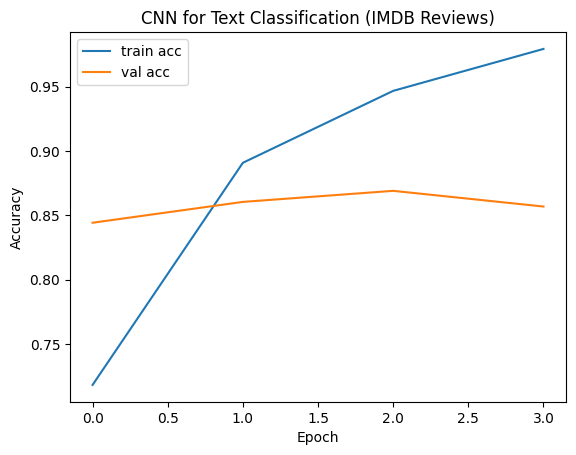

In [5]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN for Text Classification (IMDB Reviews)')
plt.legend()
plt.show()


In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n✅ Test accuracy: {test_acc*100:.2f}%")


782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8467 - loss: 0.4959

✅ Test accuracy: 84.68%


In [7]:
# Decode review to text (optional)
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print("Example decoded review:\n", decode_review(x_train[0]))

# Predict on one review
sample = np.expand_dims(x_test[0], axis=0)
prediction = model.predict(sample)[0][0]
print("\nPrediction score:", prediction)
print("Sentiment:", "Positive 😊" if prediction > 0.5 else "Negative 😠")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Example decoded review:
 and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it 